# 🌎 Módulo 2 — Análise Espacial Aplicada ao Monitoramento do Crédito Rural
## Bloco 3: Interpolação Espacial — IDW, Spline e Krigagem

**Curso Geotec G4** — Projeto FiBraS II / BCB · GIZ · TCU  
**Duração:** ~2 horas  

---

### O que vamos aprender neste bloco?

Nos Blocos 1 e 2, trabalhamos com os **dados do Sicor** — as COPs de soja com suas
coordenadas. Agora vamos trabalhar com os **dados meteorológicos das estações INMET**.

O problema central é:

> **Uma COP comunica perda por seca em uma gleba que fica a 40 km da estação
> meteorológica mais próxima. Qual era a precipitação naquele local?**

Como estações meteorológicas são pontos fixos no espaço, e as glebas podem estar
em qualquer lugar, precisamos **estimar** os valores climáticos em locais sem
medição direta. Isso se chama **interpolação espacial**.

| Técnica | Ideia central | Complexidade |
|---------|--------------|-------------|
| **IDW** | Vizinhos mais pertos pesam mais | Simples |
| **Spline (RBF)** | Ajusta uma superfície suave pelos pontos | Intermediário |
| **Krigagem** | Usa a estrutura de correlação espacial dos dados | Avançado |

### Dados utilizados
- `sicor-interest-data.csv` — COPs de soja georreferenciadas (RS/PR)
- `CatalogoEstacoesAutomaticas.csv` — localização das estações INMET
- Arquivos CSV horários das estações INMET (organizados em pastas por ano)

> ⚠️ **Este material é exclusivamente didático.**

---

Neste bloco, vamos usar **três fontes de dados**:
1. O `sicor-interest-data.csv` (localização das COPs)
2. O catálogo de estações INMET (localização das estações)
3. Os dados meteorológicos horários das estações (precipitação, temperatura)

## 0.1 Instalação e importações

In [1]:
# Instalação das bibliotecas necessárias para o Bloco 3
!pip install cartopy geopandas pykrige scikit-gstat -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 710.3/710.3 kB 27.4 MB/s eta 0:00:00


## 0.2 Leitura das COPs do Sicor

Vamos recarregar o arquivo de COPs — precisamos das coordenadas das glebas
para, no final do bloco, cruzar com as superfícies interpoladas.

In [2]:
# monta o meu drive aqui no colab/máquina virtual
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd /content/drive/MyDrive/MaterialGeotec/basededados/

/content/drive/MyDrive/MaterialGeotec/basededados


In [4]:
import pandas as pd

df_cop = pd.read_csv('sicor-interest-data.csv')

df_cop = df_cop.rename(columns={'latitude_centroide':'latitude', 'longitude_centroide':'longitude'})

# Converter latitude e longitude para números
df_cop['longitude'] = pd.to_numeric(df_cop['longitude'], errors='coerce')
df_cop['latitude']  = pd.to_numeric(df_cop['latitude'],  errors='coerce')

# Converter área para número
df_cop['area_gleba_ha'] = pd.to_numeric(df_cop['area_gleba_ha'], errors='coerce')

# Converter ano para número inteiro
df_cop['ano_emissao'] = pd.to_numeric(df_cop['ano_emissao'], errors='coerce')

# Converter colunas de datas
colunas_datas = [
    'dt_inicio_evento', 'dt_fim_evento', 'dt_comunicacao',
    'dt_inicio_plantio', 'dt_fim_plantio',
    'dt_inicio_colheita', 'dt_fim_colheita',
]
for col in colunas_datas:
    df_cop[col] = pd.to_datetime(df_cop[col], errors='coerce')

# Conversões de tipo
df_cop['longitude'] = pd.to_numeric(df_cop['longitude'], errors='coerce')
df_cop['latitude']  = pd.to_numeric(df_cop['latitude'],  errors='coerce')
df_cop['area_gleba_ha'] = pd.to_numeric(df_cop['area_gleba_ha'], errors='coerce')
df_cop['ano_emissao'] = pd.to_numeric(df_cop['ano_emissao'], errors='coerce')
df_cop['cd_ibge_municipio'] = df_cop['cd_ibge_municipio'].astype(str)

# Remover registros sem coordenadas
df_cop = df_cop.dropna(subset=['longitude', 'latitude'])

print(f"COPs carregadas: {len(df_cop)} registros")

COPs carregadas: 1314604 registros


## 0.3 Leitura do Catálogo de Estações INMET

O catálogo contém a **localização geográfica** de todas as estações automáticas do INMET.
Vamos filtrar apenas as estações do RS e PR.

In [5]:
import pandas as pd

# Leitura do catálogo de estações
df_catalogo = pd.read_csv('coordenadas-inmet.csv', header=0, names=['cod', 'latitude', 'longitude'])

# Vamos ver quais colunas existem
print("Colunas do catálogo:")
print(list(df_catalogo.columns))
print()
print("Primeiras linhas:")
df_catalogo.head()

Colunas do catálogo:
['cod', 'latitude', 'longitude']

Primeiras linhas:


,cod,latitude,longitude
0,A042,-15.599722,-48.131111
1,A045,-15.596491,-47.625801
2,A046,-15.935278,-48.137500
3,A047,-16.012222,-47.557417
4,A002,-16.642778,-49.220278


## 0.4 Leitura dos dados horários das estações INMET

Os dados meteorológicos do INMET vêm em arquivos CSV, um por estação e por ano.
Cada arquivo tem **8 linhas de cabeçalho** com metadados e depois **19 colunas**
de dados horários.

Vamos ler todos os arquivos disponíveis das estações do RS e PR.

> 📁 **Estrutura esperada dos arquivos:**
> ```
> INMET/
> ├── 2021/
> │   ├── INMET_S_RS_A801_PORTO ALEGRE_01-01-2021_A_31-12-2021.CSV
> │   └── ...
> ├── 2022/
> │   └── ...
> └── 2023/
>     └── ...
> ```

### Nomes padronizados das 19 colunas do INMET

Cada arquivo do INMET tem 19 colunas, sempre na mesma ordem. Vamos definir os
nomes que usaremos.

In [6]:
# Nomes padronizados para as 19 colunas do INMET
COLUNAS_INMET = [
    'DATA',          # Data da medição
    'HORA',          # Hora (UTC)
    'PREC',          # Precipitação total horária (mm)
    'PATM',          # Pressão atmosférica na estação (mB)
    'PATM_MAX',      # Pressão atm máxima na hora anterior (mB)
    'PATM_MIN',      # Pressão atm mínima na hora anterior (mB)
    'RAD',           # Radiação global (KJ/m²)
    'TEMP',          # Temperatura do ar (bulbo seco) (°C)
    'TD',            # Temperatura do ponto de orvalho (°C)
    'TMAX',          # Temperatura máxima na hora anterior (°C)
    'TMIN',          # Temperatura mínima na hora anterior (°C)
    'TD_MAX',        # Temp. orvalho máxima na hora anterior (°C)
    'TD_MIN',        # Temp. orvalho mínima na hora anterior (°C)
    'UR_MAX',        # Umidade relativa máxima (%)
    'UR_MIN',        # Umidade relativa mínima (%)
    'UR',            # Umidade relativa do ar (%)
    'VENTO_DIR',     # Direção do vento (graus)
    'VENTO_RAJ',     # Rajada máxima de vento (m/s)
    'VENTO_VEL',     # Velocidade do vento (m/s)
]

### Leitura dos arquivos CSV — passo a passo

Vamos percorrer todos os arquivos CSV dentro da pasta `INMET/`, ler cada um,
padronizar as colunas, e juntar tudo em uma tabela única.

> ⚠️ Este passo pode demorar alguns minutos dependendo do volume de dados.

In [7]:
import pandas as pd
import glob

# Buscar todos os arquivos CSV dentro da pasta INMET (em qualquer subpasta)
arquivos_inmet = glob.glob('INMET/**/*.CSV', recursive=True)

print(f"Arquivos INMET encontrados: {len(arquivos_inmet)}")

Arquivos INMET encontrados: 7289


In [8]:
import pandas as pd
import glob
import os # Import the os module

# Lista para acumular os dados de cada arquivo
lista_estacoes = []
# Renomear colunas para corresponder aos nomes esperados em outras partes do notebook
df_estacoes = df_catalogo.copy().rename(columns={ # Initialize df_estacoes from df_catalogo
    'latitude': 'lat_estacao',
    'longitude': 'lon_estacao'
})
# Adicionar uma coluna de nome da estação, se ela não existir no catálogo
if 'nome_estacao' not in df_estacoes.columns:
    df_estacoes['nome_estacao'] = 'Estação ' + df_estacoes['cod']

# -----------------------------------------------------

# Pegar os códigos das estações
codigos = df_estacoes['cod'].tolist()

# Percorrer cada arquivo
arquivos_inmet = sorted(glob.glob('INMET/*/*_S_*.CSV', recursive=True))

for arquivo in arquivos_inmet:
    # Ler o CSV: pular as 8 primeiras linhas (cabeçalho de metadados)
    print(arquivo)
    df_arq = pd.read_csv(
        arquivo,
        encoding='latin1',
        sep=';',
        decimal=',',
        skiprows=8,
        na_values=[-9999]
    )

    # Remover coluna vazia no final (causada pelo ; no final de cada linha)
    df_arq = df_arq.loc[:, ~df_arq.columns.str.startswith('Unnamed')]

    # Renomear colunas pela posição (pois o cabeçalho original varia)
    df_arq.columns = COLUNAS_INMET[:len(df_arq.columns)]

    # Padronizar a coluna HORA
    # Pode vir como "0000 UTC" ou "00:00" — vamos unificar para "HH:MM"
    df_arq['HORA'] = (
        df_arq['HORA'].astype(str).str.strip()
        .str.replace(' UTC', '', regex=False)
        .str.replace(r'^(\d{2})(\d{2})$', r'\1:\2', regex=True)
    )

    # Padronizar a coluna DATA
    df_arq['DATA'] = df_arq['DATA'].astype(str).str.replace('/', '-')

    # Adicionar código da estação
    # Extract station code from filename (e.g., A801 from INMET_S_RS_A801...)
    filename = os.path.basename(arquivo)
    parts = filename.split('_')
    codigo_estacao = parts[3] # Assuming the code is the 4th part
    df_arq['COD'] = codigo_estacao

    # Converter colunas numéricas
    for col in COLUNAS_INMET[2:]:  # Pular DATA e HORA
        if col in df_arq.columns:
            df_arq[col] = pd.to_numeric(df_arq[col], errors='coerce')

    lista_estacoes.append(df_arq)

# Juntar tudo
df_meteo = pd.concat(lista_estacoes, ignore_index=True)

# Criar índice datetime
df_meteo['datetime'] = pd.to_datetime(df_meteo['DATA'] + ' ' + df_meteo['HORA'])

print(f"Dados meteorológicos carregados: {len(df_meteo):,} registros horários")
print(f"Estações: {df_meteo['COD'].nunique()}")
print(f"Período: {df_meteo['datetime'].min()} a {df_meteo['datetime'].max()}")

INMET/2014/INMET_S_PR_A807_CURITIBA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A818_IVAI_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A819_CASTRO_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A820_MAL. CANDIDO RONDON_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A821_JOAQUIM TAVORA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A822_NOVA TEBAS_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A823_INACIO MARTINS_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A824_ICARAIMA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A835_MARINGA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A842_NOVA FATIMA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A843_DOIS VIZINHOS_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A846_FOZ DO IGUACU_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A847_ILHA DO MEL_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A849_DIAMANTE DO NORTE_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A850_PARANAPOEMA_01-01-2014_A_31-12-201

In [9]:
df_meteo

,DATA,HORA,PREC,PATM,PATM_MAX,PATM_MIN,RAD,TEMP,TD,TMAX,...,TD_MAX,TD_MIN,UR_MAX,UR_MIN,UR,VENTO_DIR,VENTO_RAJ,VENTO_VEL,COD,datetime
0,2014-01-01,00:00,0.0,908.4,908.4,907.1,NaN,24.5,17.8,26.2,...,18.1,17.3,66.0,60.0,66.0,251.0,7.7,3.4,A807,2014-01-01 00:00:00
1,2014-01-01,01:00,0.0,908.7,908.7,908.4,NaN,24.0,17.7,24.5,...,17.8,17.5,68.0,65.0,68.0,252.0,6.6,2.1,A807,2014-01-01 01:00:00
2,2014-01-01,02:00,0.0,909.0,909.1,908.7,NaN,23.5,17.4,24.0,...,17.7,17.3,69.0,67.0,69.0,279.0,4.6,2.0,A807,2014-01-01 02:00:00
3,2014-01-01,03:00,0.0,908.4,909.0,908.4,NaN,23.4,17.3,23.5,...,17.4,17.2,69.0,68.0,69.0,264.0,3.9,1.6,A807,2014-01-01 03:00:00
4,2014-01-01,04:00,0.0,908.4,908.6,908.4,NaN,22.6,18.0,23.4,...,18.0,17.2,75.0,68.0,75.0,337.0,4.8,0.9,A807,2014-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10388083,2025-12-31,19:00,0.0,898.7,899.4,898.7,1715.2,24.0,21.4,24.1,...,21.9,20.1,96.0,84.0,85.0,351.0,4.6,1.1,A898,2025-12-31 19:00:00
10388084,2025-12-31,20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A898,2025-12-31 20:00:00
10388085,2025-12-31,21:00,0.0,897.6,898.3,897.6,628.2,23.8,20.3,24.4,...,20.8,19.7,81.0,77.0,81.0,193.0,3.0,1.1,A898,2025-12-31 21:00:00
10388086,2025-12-31,22:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A898,2025-12-31 22:00:00


## 0.5 Agregação diária da precipitação

Os dados do INMET são **horários**, mas para a interpolação vamos trabalhar com
precipitação **acumulada por dia** em cada estação. Isso simplifica a análise
e é suficiente para o contexto do Proagro.

In [10]:
import pandas as pd

# Extrair a data (sem hora) a partir do datetime
df_meteo['data'] = df_meteo['datetime'].dt.date

# Precipitação diária = soma dos valores horários do dia em cada estação
prec_diaria = (
    df_meteo
    .groupby(['COD', 'data'])['PREC']
    .sum()
    .reset_index()
)
prec_diaria.columns = ['cod_estacao', 'data', 'prec_mm']

# Converter data para datetime
prec_diaria['data'] = pd.to_datetime(prec_diaria['data'])

print(f"Precipitação diária calculada: {len(prec_diaria):,} registros")
print(f"Estações: {prec_diaria['cod_estacao'].nunique()}")
print(f"Período: {prec_diaria['data'].min().date()} a {prec_diaria['data'].max().date()}")

Precipitação diária calculada: 400,094 registros
Estações: 121
Período: 2014-01-01 a 2025-12-31


In [11]:
prec_diaria.index = pd.to_datetime(prec_diaria['data'])
prec_diaria.drop('data', axis=1, inplace=True)
prec_diaria

,cod_estacao,prec_mm
data,,
2014-01-01,A801,0.0
2014-01-02,A801,0.4
2014-01-03,A801,13.8
2014-01-04,A801,0.0
2014-01-05,A801,0.0
...,...,...
2025-12-27,B841,16.1
2025-12-28,B841,0.4
2025-12-29,B841,7.3


In [12]:
grouper = [ prec_diaria.index.year, prec_diaria.index.month, prec_diaria.cod_estacao ]
prec_mensal = prec_diaria['prec_mm'].groupby(grouper).sum()
# Correctly assign names to the index levels of the MultiIndex
prec_mensal.index.names = ['ano', 'mes', 'cod_estacao']
# Explicitly name the Series values if not already 'prec_mm'
prec_mensal.name = 'prec_mm'

In [13]:
prec_mensal

ano   mes  cod_estacao
2014  1    A801            75.6
           A802           201.4
           A803           139.6
           A804             0.0
           A805             0.0
                          ...  
2025  12   B830            58.6
           B832           239.7
           B836           101.6
           B839           151.8
           B841           190.2
Name: prec_mm, Length: 13158, dtype: float64

In [14]:
prec_diaria

,cod_estacao,prec_mm
data,,
2014-01-01,A801,0.0
2014-01-02,A801,0.4
2014-01-03,A801,13.8
2014-01-04,A801,0.0
2014-01-05,A801,0.0
...,...,...
2025-12-27,B841,16.1
2025-12-28,B841,0.4
2025-12-29,B841,7.3


In [15]:
grouper = [prec_diaria.index.month, prec_diaria.index.day, prec_diaria.cod_estacao ]
climatologia = prec_diaria.groupby(grouper).mean()
climatologia.index.names = ['mes', 'dia', 'cod_estacao']
climatologia

prec_mm
mes dia cod_estacao           
1   1   A801          3.316667
        A802          7.066667
        A803          3.233333
        A804          2.350000
        A805         11.016667
...                        ...
12  31  B830          0.000000
        B832          0.200000
        B836          0.000000
        B839          0.000000
        B841          1.600000

[38863 rows x 1 columns]

## 0.6 Juntar coordenadas das estações à precipitação

Cada estação tem uma posição geográfica fixa (do catálogo). Vamos adicionar
as coordenadas à tabela de precipitação diária.

In [16]:
import pandas as pd

# Garantir que o código da estação é string em ambas as tabelas
prec_diaria['cod_estacao'] = prec_diaria['cod_estacao'].astype(str)
df_estacoes['cod'] = df_estacoes['cod'].astype(str)

# Juntar coordenadas
prec_com_coords = prec_diaria.reset_index().merge(
    df_estacoes[['cod', 'lat_estacao', 'lon_estacao']],
    left_on='cod_estacao',
    right_on='cod',
    how='inner',
)
prec_com_coords.set_index('data', inplace=True)


print(f"Registros com coordenadas: {len(prec_com_coords):,}")
print(f"Estações com dados: {prec_com_coords['cod_estacao'].nunique()}")
print(prec_com_coords.head(5))

Registros com coordenadas: 390,889
Estações com dados: 94
           cod_estacao  prec_mm   cod  lat_estacao  lon_estacao
data                                                           
2014-01-01        A801      0.0  A801   -30.053611   -51.174722
2014-01-02        A801      0.4  A801   -30.053611   -51.174722
2014-01-03        A801     13.8  A801   -30.053611   -51.174722
2014-01-04        A801      0.0  A801   -30.053611   -51.174722
2014-01-05        A801      0.0  A801   -30.053611   -51.174722


## 0.7 Escolher uma data para as interpolações

Para demonstrar as técnicas de interpolação, vamos escolher **um dia específico**
e interpolar a precipitação nesse dia. Vamos usar um dia em que houve uma safra
com muitas COPs — por exemplo, o período da seca de 2021/2022.

> 💡 **Ideia:** Vamos escolher um dia dentro do período de um evento adverso
> frequente nas COPs. Assim, a interpolação terá conexão direta com o problema
> do Proagro.

In [17]:
import pandas as pd

# Vamos ver quais períodos tiveram mais COPs por Seca
cops_seca = df_cop[df_cop['nome_evento'] == 'Seca'].copy()
cops_seca['mes_evento'] = cops_seca['dt_inicio_evento'].dt.to_period('M')

print("Meses com mais COPs por Seca:")
top_meses = cops_seca['mes_evento'].value_counts().head(10)
print(top_meses.to_string())

Meses com mais COPs por Seca:
mes_evento
2022-12    108687
2021-11     88120
2022-11     67750
2023-01     66185
2021-12     57755
2019-12     22371
2020-09     20009
2023-12     19799
2021-10     19121
2021-03     18615
Freq: M


In [18]:
import pandas as pd

# Definir o ano e mês para calcular a anomalia
ano_selecionado = 2022
mes_selecionado = 12

# Extrair a precipitação do ano e mês selecionados
# Isso retorna uma Series com o índice 'cod_estacao'
prec_mes = prec_mensal.loc[ano_selecionado, mes_selecionado]

# Extrair a climatologia para o mesmo mês
# climatologia is indexed by (mes, dia, cod_estacao), values are avg daily prec.
# To get monthly climatology, we need to sum the daily averages for the month.
# First, select the month, which results in a Series indexed by (dia, cod_estacao)
clim_daily_for_month = climatologia.loc[mes_selecionado]

# Then, group by cod_estacao and sum the daily averages to get monthly climatology
# Explicitly select 'prec_mm' to ensure the result is a Series
clim_mes = clim_daily_for_month.groupby(level='cod_estacao')['prec_mm'].sum()

# Calcular a anomalia (valor observado - climatologia)
# O Pandas alinha automaticamente os dados estação a estação usando o índice
anomalia = prec_mes - clim_mes

# Juntar tudo em um DataFrame para visualização
df_anomalia = pd.DataFrame({
    'prec_observada': prec_mes,
    'climatologia': clim_mes,
    'anomalia': anomalia
}).dropna() # Remove estações sem dados para a comparação

print(f"Anomalia calculada para {mes_selecionado}/{ano_selecionado}:")
df_anomalia.head(10)

Anomalia calculada para 12/2022:


,prec_observada,climatologia,anomalia
cod_estacao,,,
A801,63.6,118.250000,-54.650000
A802,17.4,70.575000,-53.175000
A803,53.0,134.750000,-81.750000
A804,48.0,89.733333,-41.733333
A805,69.4,117.883333,-48.483333
A806,460.4,184.300000,276.100000
A807,167.6,135.600000,32.000000
A808,111.6,113.860000,-2.260000
A809,39.4,136.400000,-97.000000


In [19]:
# 1. Transformar o índice (cod_estacao) em uma coluna real
df_anomalia_reset = df_anomalia.reset_index().rename(columns={'index': 'cod_estacao'})

# 2. Garantir que os códigos são strings para o merge
df_anomalia_reset['cod_estacao'] = df_anomalia_reset['cod_estacao'].astype(str)
df_estacoes['cod'] = df_estacoes['cod'].astype(str)

# 3. Juntar as coordenadas usando a coluna 'cod_estacao'
anomalia_com_coords = df_anomalia_reset.merge(
    df_estacoes[['cod', 'lat_estacao', 'lon_estacao', 'nome_estacao']],
    left_on='cod_estacao',
    right_on='cod',
    how='inner'
)

print(f"Estações com anomalia e coordenadas: {len(anomalia_com_coords)}")
anomalia_com_coords.head()

Estações com anomalia e coordenadas: 92


,cod_estacao,prec_observada,climatologia,anomalia,cod,lat_estacao,lon_estacao,nome_estacao
0,A801,63.6,118.250000,-54.650000,A801,-30.053611,-51.174722,Estação A801
1,A802,17.4,70.575000,-53.175000,A802,-32.078889,-52.167778,Estação A802
2,A803,53.0,134.750000,-81.750000,A803,-29.725000,-53.720556,Estação A803
3,A804,48.0,89.733333,-41.733333,A804,-30.750556,-55.401389,Estação A804
4,A805,69.4,117.883333,-48.483333,A805,-27.854444,-53.791111,Estação A805


### Mapa de contexto: estações e COPs no mesmo dia

Vamos visualizar as estações INMET (com o valor de precipitação) e as COPs
de Seca que ocorreram naquele período, para entender o "cenário" espacial.

In [20]:
# COPs de Seca no período (± 30 dias da data escolhida)
data_ref = pd.to_datetime('2022-12')
margem = pd.Timedelta(days=30)
cops_periodo = cops_seca[
    (cops_seca['dt_inicio_evento'] >= data_ref - margem) &
    (cops_seca['dt_inicio_evento'] <= data_ref + margem)
]
cops_periodo.iloc[0]

,28
ref_bacen,514249818
status_cop,deferida
nome_evento,Seca
produto,soja
descricao_ciclo,grupo ii
dt_inicio_evento,2022-12-15 00:00:00
dt_fim_evento,2023-01-14 00:00:00
dt_comunicacao,2023-03-17 00:00:00
cd_cpf_perito,NaN
dt_inicio_plantio,2022-11-08 00:00:00


In [21]:
# pega aqui os dados de chuva acumulada para o mesmo período das cops
prec_periodo = prec_com_coords[
      (prec_com_coords.index >= data_ref - margem) &
      (prec_com_coords.index <= data_ref + margem)
]

# aqui faz o groupby, somando a precipitação e mantendo as lat lon first
prec_periodo = prec_periodo.groupby('cod').agg({
    'prec_mm': 'sum',
    'lat_estacao': 'first',
    'lon_estacao': 'first'
}).reset_index()
prec_periodo

,cod,prec_mm,lat_estacao,lon_estacao
0,A801,115.8,-30.053611,-51.174722
1,A802,67.2,-32.078889,-52.167778
2,A803,95.4,-29.725000,-53.720556
3,A804,90.6,-30.750556,-55.401389
4,A805,92.2,-27.854444,-53.791111
...,...,...,...,...
87,A899,136.2,-33.742222,-53.372222
88,B803,78.0,-24.570833,-52.800278
89,B804,371.0,-25.371389,-52.400833
90,B806,345.2,-25.322464,-49.157733


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242

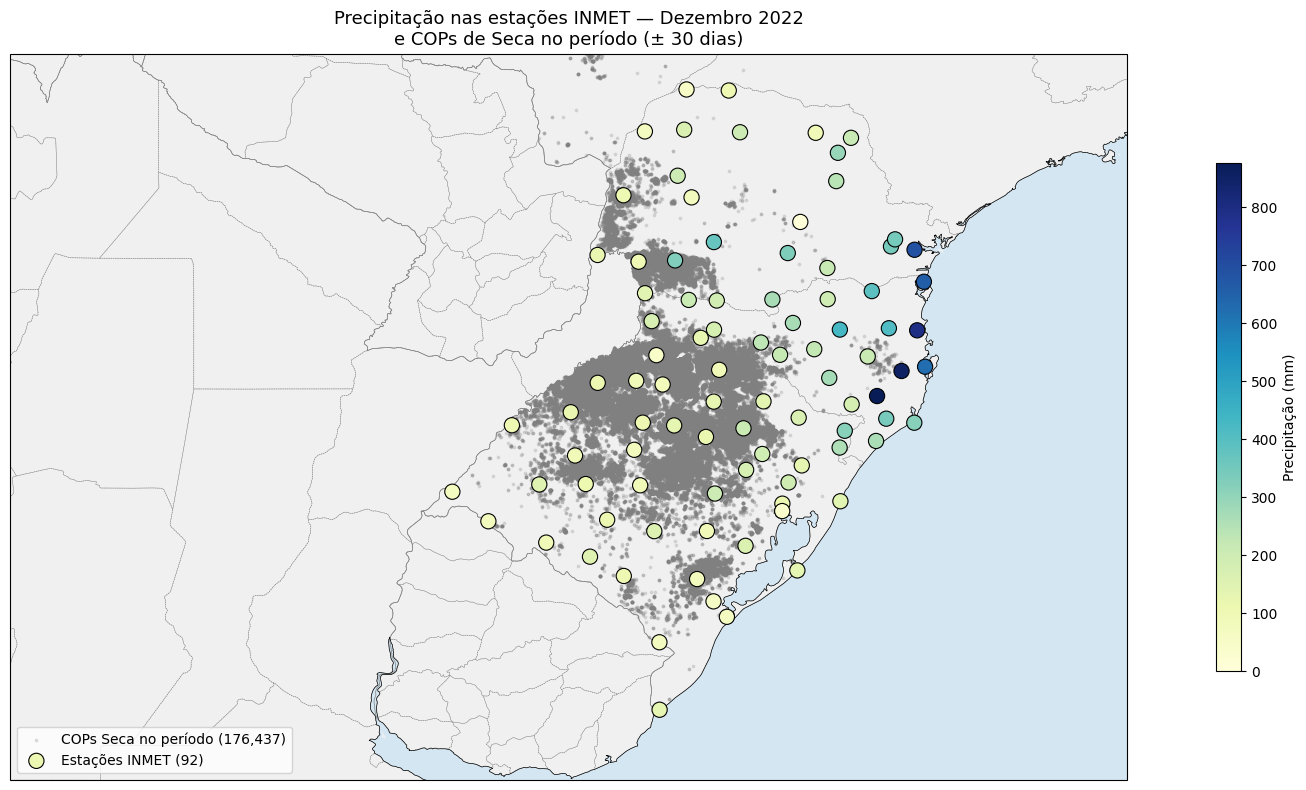

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

fig, ax = plt.subplots(1,1, figsize=(18, 8), subplot_kw={'projection': proj})

# Plotar COPs como pontos pequenos cinza
ax.scatter(
    cops_periodo['longitude'], cops_periodo['latitude'],
    s=3, alpha=0.2, color='gray',
    label=f'COPs Seca no período ({len(cops_periodo):,})',
    transform=proj
)

# Plotar estações coloridas pela precipitação
scatter = ax.scatter(
    prec_periodo['lon_estacao'], prec_periodo['lat_estacao'],
    c=prec_periodo['prec_mm'],
    s=120,
    cmap='YlGnBu',
    edgecolors='black',
    linewidth=0.8,
    zorder=5,
    label=f'Estações INMET ({len(prec_periodo)})',
    transform=proj
)

plt.colorbar(scatter, ax=ax, shrink=0.7, label='Precipitação (mm)')
ax.set_extent([-65,-45, -35, -22])
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Precipitação nas estações INMET — Dezembro 2022\n'
             f'e COPs de Seca no período (± 30 dias)', fontsize=13)
ax.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()



> **Observe:** As estações são **pontos esparsos** no território. Muitas glebas
> (pontos cinza) ficam longe de qualquer estação. É justamente para preencher
> esses "vazios" que precisamos da interpolação espacial.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import gaussian_kde

# ============================================
# CÁLCULO DO KDE
# ============================================

# Extraindo os dados do seu DataFrame
longitudes = cops_periodo['longitude'].values
latitudes = cops_periodo['latitude'].values

# Removendo NaNs se existirem
mask = ~(np.isnan(longitudes) | np.isnan(latitudes))
longitudes = longitudes[mask]
latitudes = latitudes[mask]

# Definindo limites com margem de 0.5 graus
x_min, x_max = longitudes.min() - 0.5, longitudes.max() + 0.5
y_min, y_max = latitudes.min() - 0.5, latitudes.max() + 0.5

# Criando grade para o KDE (100x100 pontos)
grid_size = 100
xi = np.linspace(x_min, x_max, grid_size)
yi = np.linspace(y_min, y_max, grid_size)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Calculando o KDE
positions = np.vstack([xi_grid.ravel(), yi_grid.ravel()])
values = np.vstack([longitudes, latitudes])
kernel = gaussian_kde(values, bw_method=0.05)
density = kernel(positions).reshape(xi_grid.shape)


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


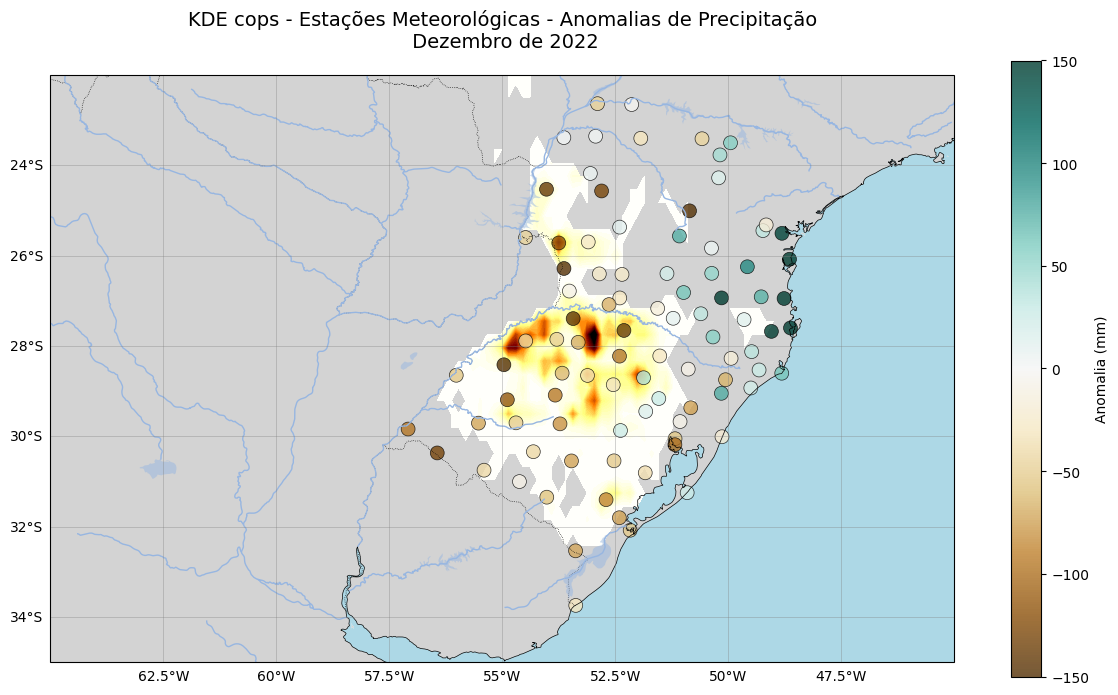

In [24]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


#Criando geometria (pontos)
geometry = [Point(xy) for xy in zip(anomalia_com_coords['lon_estacao'], anomalia_com_coords['lat_estacao'])]

# Criando GeoDataFrame
gdf = gpd.GeoDataFrame(anomalia_com_coords, geometry=geometry, crs='EPSG:4326')

# Plot com Cartopy
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Adicionando features do mapa
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Plotar COPs como pontos pequenos cinza
ax.contourf(xi_grid, yi_grid, np.where(density<=0.0001, np.nan, density), levels=np.arange(0,.5,.01), cmap='afmhot_r', extend='both')

# Plotando os pontos
# Usando diferentes cores baseadas na anomalia
scatter = ax.scatter(gdf.geometry.x, gdf.geometry.y,
                     c=gdf['anomalia'], cmap='BrBG', vmin=-150, vmax=150,
                     s=100, transform=ccrs.PlateCarree(),
                     edgecolors='black', linewidth=0.5, alpha=0.8)


# Adicionando título e barra de cores
plt.colorbar(scatter, ax=ax, label='Anomalia (mm)', shrink=0.8)

# Configurando limites do mapa para focar na região
# Ajuste conforme necessário baseado nas coordenadas
ax.set_extent([-65, -45, -35, -22], crs=ccrs.PlateCarree())

# Adicionando gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

plt.title('KDE cops - Estações Meteorológicas - Anomalias de Precipitação\n Dezembro de 2022', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 0.8 Preparar os arrays para a interpolação

Todas as três técnicas (IDW, Spline, Krigagem) precisam dos mesmos dados de entrada:
- **Coordenadas dos pontos conhecidos** (estações): longitude e latitude
- **Valores observados** nesses pontos: precipitação acumulada
- **Grade de destino**: onde queremos estimar os valores

In [25]:
anomalia_com_coords

,cod_estacao,prec_observada,climatologia,anomalia,cod,lat_estacao,lon_estacao,nome_estacao
0,A801,63.6,118.250000,-54.650000,A801,-30.053611,-51.174722,Estação A801
1,A802,17.4,70.575000,-53.175000,A802,-32.078889,-52.167778,Estação A802
2,A803,53.0,134.750000,-81.750000,A803,-29.725000,-53.720556,Estação A803
3,A804,48.0,89.733333,-41.733333,A804,-30.750556,-55.401389,Estação A804
4,A805,69.4,117.883333,-48.483333,A805,-27.854444,-53.791111,Estação A805
...,...,...,...,...,...,...,...,...
87,A899,49.4,79.933333,-30.533333,A899,-33.742222,-53.372222,Estação A899
88,B803,45.2,176.060000,-130.860000,B803,-24.570833,-52.800278,Estação B803
89,B804,180.6,170.020000,10.580000,B804,-25.371389,-52.400833,Estação B804
90,B806,118.8,136.420000,-17.620000,B806,-25.322464,-49.157733,Estação B806


In [26]:
# Coordenadas das estações (pontos conhecidos)
lon_estacoes = anomalia_com_coords['lon_estacao'].values
lat_estacoes = anomalia_com_coords['lat_estacao'].values
anomalia = anomalia_com_coords['anomalia'].values


In [48]:
anomalia

array([ -54.65      ,  -53.175     ,  -81.75      ,  -41.73333333,
        -48.48333333,  276.1       ,   32.        ,  -97.        ,
        -45.76666667,  -88.48333333,  -74.09166667,   26.65      ,
         27.6       ,  -17.18333333,  -25.83333333,   73.88333333,
       -152.11666667, -139.56666667,   56.61666667,   75.21666667,
          1.45      ,    6.14285714,  -72.78333333,  -59.45      ,
       -138.99166667,  -65.91666667,  -55.16666667, -131.95      ,
        -42.9       , -116.2       ,  -19.925     ,  -31.16666667,
        -72.38333333,  -33.26666667,  -37.98333333,  -95.08333333,
         27.83333333,  -15.1       ,  -45.2       ,  -27.16666667,
        -29.46666667,   34.51666667,  -45.98333333, -163.01666667,
        -47.68333333,   -2.61666667,  217.88333333, -149.34166667,
        -63.68333333, -143.95833333, -118.76666667,  -68.71666667,
         -6.68333333,  -30.38333333,   62.85      ,   32.26666667,
        181.75      ,   98.38333333,   13.76666667,   50.7    

In [27]:
import numpy as np

# Grade de destino (mesma lógica do KDE no Bloco 1)
lon_min = lon_estacoes.min() - 0.5
lon_max = lon_estacoes.max() + 0.5
lat_min = lat_estacoes.min() - 0.5
lat_max = lat_estacoes.max() + 0.5

# Grade 150x150 (reduzida para caber no Colab sem travar)
grade_lon = np.linspace(lon_min, lon_max, 150)
grade_lat = np.linspace(lat_min, lat_max, 150)
grade_lon_2d, grade_lat_2d = np.meshgrid(grade_lon, grade_lat)

print(f"Grade de destino: {grade_lon_2d.shape[0]} × {grade_lon_2d.shape[1]} = {grade_lon_2d.size:,} pontos")

Grade de destino: 150 × 150 = 22,500 pontos


✅ Pronto! Agora temos tudo que precisamos para começar a interpolar:
- `lon_estacoes`, `lat_estacoes` — posição das estações
- `prec_observada` — precipitação observada em cada estação
- `grade_lon_2d`, `grade_lat_2d` — grade de destino

Vamos começar pela técnica mais simples: **IDW**.

---
# Parte 1 — IDW (Inverse Distance Weighting)

## 1.1 O que é o IDW?

O **IDW (Ponderação pelo Inverso da Distância)** é a técnica de interpolação mais
intuitiva. A ideia é extremamente simples:

> **O valor em um ponto desconhecido é a média ponderada dos valores conhecidos,
> onde o peso de cada ponto é inversamente proporcional à sua distância.**

Em outras palavras: **estações mais perto pesam mais** na estimativa.

**Analogia:** Imagine que você está parado em um ponto do mapa e quer saber
a temperatura. Existem 3 termômetros ao redor:
- Um a 10 km marca 25°C
- Um a 50 km marca 20°C
- Um a 100 km marca 15°C

O IDW diz: o termômetro a 10 km é muito mais relevante que o de 100 km.
A estimativa será mais próxima de 25°C do que de 15°C.

**Parâmetro-chave: a potência (power)**
- `power = 1` → peso decai lentamente com a distância
- `power = 2` → peso decai mais rápido (mais comum)
- `power = 3` → peso decai muito rápido (quase só o vizinho mais perto conta)

## 1.2 IDW na prática — Passo a passo

A fórmula do IDW é:

$$\hat{z}(x_0) = \frac{\sum_{i=1}^{n} \frac{z_i}{d_i^p}}{\sum_{i=1}^{n} \frac{1}{d_i^p}}$$

Onde:
- $\hat{z}(x_0)$ = valor estimado no ponto desconhecido
- $z_i$ = valor observado na estação $i$
- $d_i$ = distância do ponto desconhecido à estação $i$
- $p$ = potência (geralmente 2)

Vamos implementar isso passo a passo usando a função `griddata` do SciPy,
que já faz o cálculo pesado para nós.

> **Nota:** O `griddata` não implementa o IDW diretamente, mas oferece métodos
> similares. Vamos implementar o IDW "na mão" para entender a lógica, e depois
> usar o `griddata` para comparar.

### Implementação manual do IDW

Vamos calcular o IDW ponto a ponto na grade. Isso é mais lento que funções
otimizadas, mas permite entender cada passo.

In [28]:
import numpy as np

# Parâmetro do IDW
potencia = 2

# Arrays para as coordenadas da grade "achatadas" (1D)
lon_grade_flat = grade_lon_2d.ravel()
lat_grade_flat = grade_lat_2d.ravel()

# Array para guardar os resultados
resultado_idw = np.zeros(len(lon_grade_flat))

# Para cada ponto da grade, calcular a média ponderada
for j in range(len(lon_grade_flat)):

    # Distância deste ponto da grade a CADA estação
    # Usamos distância euclidiana simples (em graus — ok para fins didáticos)
    distancias = np.sqrt(
        (lon_estacoes - lon_grade_flat[j])**2 +
        (lat_estacoes - lat_grade_flat[j])**2
    )

    # Evitar divisão por zero (se o ponto cai exatamente sobre uma estação)
    distancias[distancias == 0] = 0.00001

    # Pesos: inverso da distância elevado à potência
    pesos_idw = 1.0 / (distancias ** potencia)

    # Valor estimado: média ponderada
    resultado_idw[j] = np.sum(pesos_idw * anomalia) / np.sum(pesos_idw)

# Reorganizar para 2D
idw_2d = resultado_idw.reshape(grade_lon_2d.shape)

print(f"IDW calculado! (potência = {potencia})")
print(f"  Valores estimados: {idw_2d.min():.1f} a {idw_2d.max():.1f} mm")

IDW calculado! (potência = 2)
  Valores estimados: -162.6 a 379.5 mm


### Mapa da superfície IDW

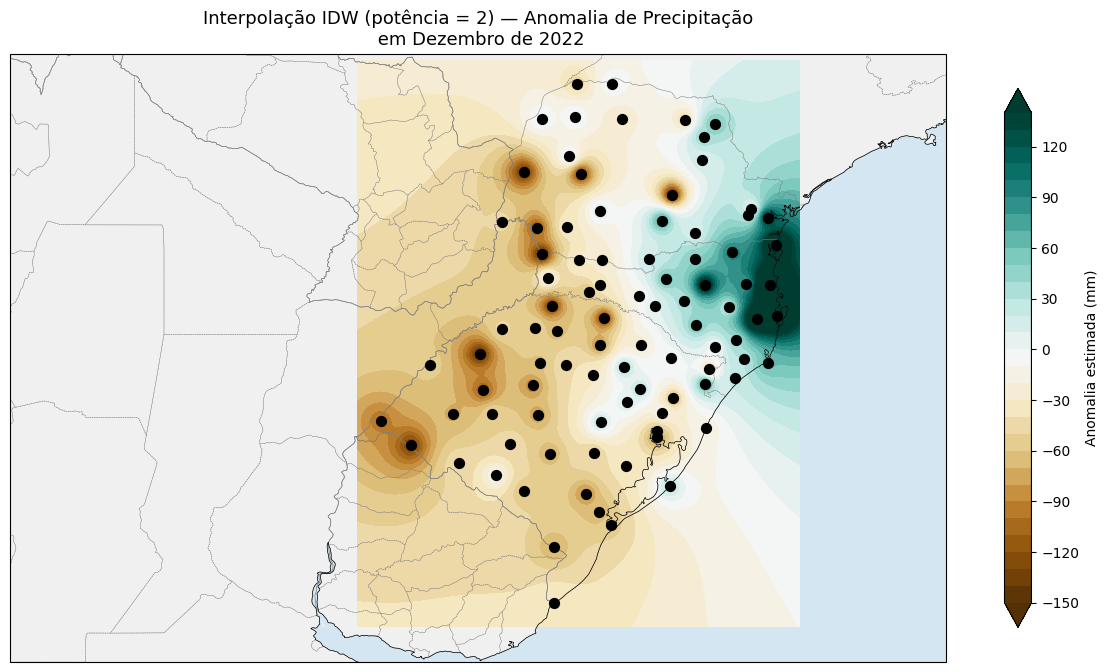

In [29]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Plot com Cartopy
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_extent([-65, -45, -35, -22], crs=ccrs.PlateCarree())


# Superfície interpolada
contorno = ax.contourf(
    grade_lon_2d, grade_lat_2d, idw_2d,
    levels=np.arange(-150,150, 10), cmap='BrBG', extend='both'
)
plt.colorbar(contorno, ax=ax, shrink=0.7, label='Anomalia estimada (mm)')

# Estações (pontos reais)
ax.scatter(
    lon_estacoes, lat_estacoes,
    s=50, color='k',
    edgecolors='black', linewidth=1, zorder=5,
)

# Adicionando features do mapa
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Interpolação IDW (potência = {potencia}) — Anomalia de Precipitação\n em Dezembro de 2022', fontsize=13)

plt.tight_layout()
plt.show()

> **Observe:** A superfície IDW tem um aspecto de "olhos de boi" ao redor de cada
> estação — os contornos circulares são típicos do IDW. Isso ocorre porque o
> método só considera a **distância**, sem levar em conta a estrutura espacial
> dos dados (ex.: direção predominante da chuva, relevo, etc.).
>
> **Vantagens:** Simples, rápido, intuitivo.  
> **Limitações:** Não produz medida de incerteza; aspecto "olhos de boi"; pode
> não capturar gradientes direcionais.

## 1.3 Efeito da potência no IDW

Assim como o bandwidth no KDE, a potência do IDW controla a suavização.
Vamos comparar.

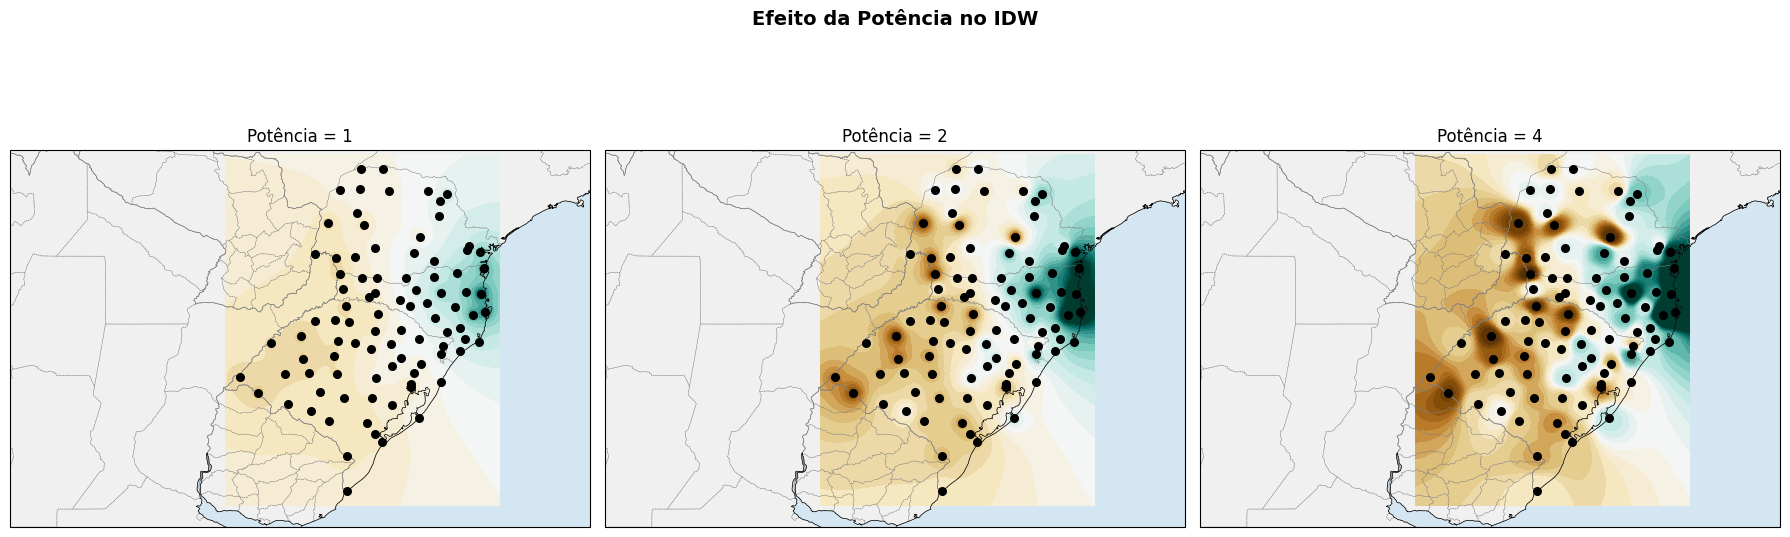

In [30]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

fig, eixos = plt.subplots(1, 3, figsize=(18, 6),subplot_kw={'projection': proj})

potencias = [1, 2, 4]
for idx, pot in enumerate(potencias):
    resultado = np.zeros(len(lon_grade_flat))
    for j in range(len(lon_grade_flat)):
        dist = np.sqrt(
            (lon_estacoes - lon_grade_flat[j])**2 +
            (lat_estacoes - lat_grade_flat[j])**2
        )
        dist[dist == 0] = 0.0001
        w = 1.0 / (dist ** pot)
        resultado[j] = np.sum(w * anomalia) / np.sum(w)

    superficie = resultado.reshape(grade_lon_2d.shape)

    ax = eixos[idx]
    ax.set_extent([-65, -45, -35, -22], crs=proj)

    cf = ax.contourf(grade_lon_2d, grade_lat_2d, superficie, levels=np.arange(-150,150, 10), cmap='BrBG', extend='both')

    ax.scatter(lon_estacoes, lat_estacoes, c='black', s=30, zorder=5)
    ax.set_title(f'Potência = {pot}', fontsize=12)
    ax.set_xlabel('Longitude')
    if idx == 0:
        ax.set_ylabel('Latitude')

    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

fig.suptitle('Efeito da Potência no IDW', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Observe:** Potência 1 gera uma superfície mais suavizada. Potência 4 faz
> com que quase só a estação mais próxima conte, criando "degraus" abruptos.
> Potência 2 é o padrão mais usado e um bom compromisso.

---
# Parte 2 — Spline (Funções de Base Radial — RBF)

## 2.1 O que é a interpolação por Spline?

O **Spline** (ou **RBF — Radial Basis Function**) ajusta uma **superfície
matematicamente suave** que passa exatamente por todos os pontos conhecidos.

Se o IDW é como colocar "cones" ao redor de cada estação, o Spline é como
esticar um **lençol elástico** que é preso em cada estação na altura do valor
medido. O lençol se deforma suavemente entre os pontos de fixação.

**Diferença-chave em relação ao IDW:**
- O IDW nunca gera valores fora da faixa dos dados observados
- O Spline **pode** gerar valores mais altos ou mais baixos que os observados
  (chamado "overshooting"), especialmente se houver poucos pontos

> 💡 **No contexto:** O Spline é útil quando queremos uma superfície suave
> (ex.: para visualização), mas é preciso cuidado com valores irreais.

## 2.2 Spline na prática

O SciPy oferece a função `Rbf` (Radial Basis Function) que implementa
a interpolação por Spline de forma direta.

In [31]:
from scipy.interpolate import Rbf
import numpy as np

# Coordenadas das estações (pontos conhecidos)
lon_estacoes = anomalia_com_coords['lon_estacao'].values
lat_estacoes = anomalia_com_coords['lat_estacao'].values
anomalia = anomalia_com_coords['anomalia'].values

# Criar o interpolador RBF (Spline)
# O parâmetro 'function' define o tipo de função de base:
#   'multiquadric' — bom para dados suaves
#   'linear'       — mais simples
#   'thin_plate'   — padrão para superfícies 2D
rbf = Rbf(
    lon_estacoes,      # Longitude das estações
    lat_estacoes,      # Latitude das estações
    anomalia,    # anomalia de precipitação
    function='thin_plate',  # Tipo de spline
)
spline_2d = rbf(grade_lon_2d, grade_lat_2d)
print("Interpolador Spline (RBF thin_plate) criado!")

Interpolador Spline (RBF thin_plate) criado!


In [49]:
spline_2d

array([[-68.3345522 , -68.17948741, -67.97873169, ..., 332.96267162,
        338.57214434, 344.2414239 ],
       [-71.36862414, -71.19963555, -70.98398221, ..., 327.95858264,
        333.53587131, 339.17416179],
       [-74.32380356, -74.14059708, -73.90965682, ..., 322.99568526,
        328.54056941, 334.14773937],
       ...,
       [-24.68245318, -25.88102602, -27.07186791, ..., 233.44671913,
        240.71397853, 248.07586372],
       [-23.97063333, -25.17462368, -26.36988643, ..., 236.65725683,
        243.92639672, 251.28593925],
       [-23.17348091, -24.38267854, -25.58221407, ..., 239.92009404,
        247.1911401 , 254.54894355]])

### Mapa da superfície Spline

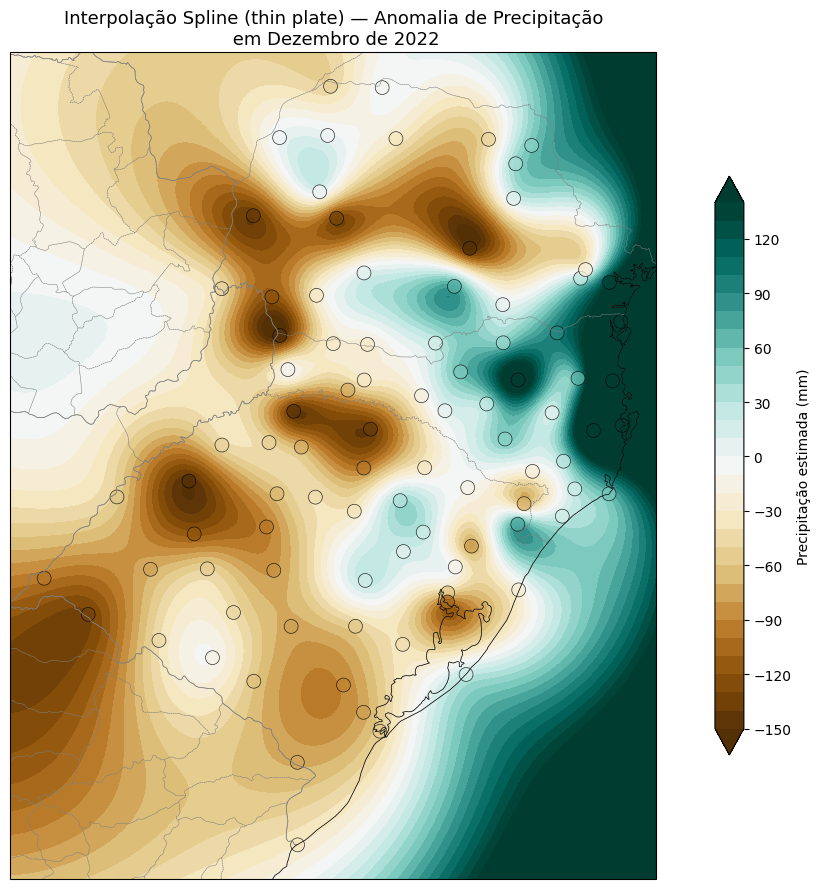

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define DATA_INTERPOLACAO for the plot title
DATA_INTERPOLACAO = 'Dezembro de 2022'

fig, ax = plt.subplots(figsize=(12, 9),
                       subplot_kw={'projection': ccrs.PlateCarree()})

contorno = ax.contourf(
    grade_lon_2d, grade_lat_2d, spline_2d,
    levels=np.arange(-150,150, 10), cmap='BrBG', extend='both'
)
plt.colorbar(contorno, ax=ax, shrink=0.7, label='Precipitação estimada (mm)')

ax.scatter(gdf.geometry.x, gdf.geometry.y,
                     c=gdf['anomalia'], cmap='BrBG', vmin=-150, vmax=150,
                     s=100, transform=ccrs.PlateCarree(),
                     edgecolors='black', linewidth=0.5, alpha=0.8)

# Add map features for consistency
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Interpolação Spline (thin plate) — Anomalia de Precipitação\n em {DATA_INTERPOLACAO}', fontsize=13)

plt.tight_layout()
plt.show()

> **Compare com o IDW:** A superfície do Spline é mais suave — não tem os
> "olhos de boi" típicos do IDW. Porém, nas bordas da área (onde há poucas
> estações), o Spline pode gerar valores irreais (muito altos ou negativos).
>
> **Vantagens:** Superfície suave, visualmente agradável.  
> **Limitações:** Pode gerar valores fora da faixa real (overshooting);
> não fornece medida de incerteza; sensível a outliers.

---
# Parte 3 — Krigagem (Kriging)

## 3.1 O que é a Krigagem?

A **Krigagem** é considerada o "padrão-ouro" da interpolação geoestatística.
Foi desenvolvida pelo engenheiro de minas sul-africano **Danie Krige** nos anos 1950
e formalizada matematicamente pelo francês **Georges Matheron** nos anos 1960.

A grande diferença da Krigagem em relação ao IDW e ao Spline:

> **A Krigagem usa a estrutura de correlação espacial dos próprios dados
> para definir os pesos da interpolação — e fornece uma estimativa da
> incerteza (variância) em cada ponto.**

Enquanto o IDW assume que "mais perto = mais peso" de forma genérica, a Krigagem
**aprende dos dados** como os valores se correlacionam no espaço. Ela modela
essa correlação através do **semivariograma**.

## 3.2 O Semivariograma — Conceito

O **semivariograma** responde à pergunta:

> "Quanto a diferença entre duas medições **cresce** conforme a distância
> entre elas **aumenta**?"

Se duas estações estão perto, esperamos que seus valores sejam parecidos
(diferença pequena). Se estão longe, os valores podem ser muito diferentes
(diferença grande).

O semivariograma é um gráfico com:
- **Eixo X:** distância entre pares de estações
- **Eixo Y:** metade da diferença quadrática média (semivariância)

Três parâmetros-chave do semivariograma:

| Parâmetro | O que significa | Analogia |
|-----------|----------------|----------|
| **Nugget** | Variabilidade a distância zero (ruído, erro de medição) | Mesmo colocando 2 termômetros no mesmo ponto, eles não marcam exatamente igual |
| **Sill** | Patamar — variabilidade máxima | Limite além do qual a distância não importa mais |
| **Range** | Alcance — distância até atingir o patamar | Até que distância as medições se influenciam? |

### Calculando e visualizando o semivariograma experimental

O semivariograma **experimental** é calculado a partir dos dados reais.
Depois, ajustamos um **modelo teórico** (curva suave) a ele.

In [34]:
import numpy as np

# Calcular o semivariograma experimental manualmente
# Para cada par de estações, calcular distância e semivariância

n_estacoes = len(lon_estacoes)
distancias_pares = []
semivariancias = []

for i in range(n_estacoes):
    for j in range(i + 1, n_estacoes):
        # Distância entre estações i e j (em graus, aproximadamente)
        dist = np.sqrt(
            (lon_estacoes[i] - lon_estacoes[j])**2 +
            (lat_estacoes[i] - lat_estacoes[j])**2
        )
        # Semivariância = metade da diferença ao quadrado
        sv = 0.5 * (anomalia[i] - anomalia[j])**2

        distancias_pares.append(dist)
        semivariancias.append(sv)

distancias_pares = np.array(distancias_pares)
semivariancias = np.array(semivariancias)

print(f"Pares calculados: {len(distancias_pares)}")
print(f"Distâncias: {distancias_pares.min():.2f} a {distancias_pares.max():.2f} graus")

Pares calculados: 4186
Distâncias: 0.13 a 11.15 graus


### Agrupando em classes de distância (bins)

Para visualizar melhor, agrupamos os pares de estações em **faixas de distância**
e calculamos a semivariância média em cada faixa.

In [35]:
import numpy as np

# Definir classes de distância (bins)
n_bins = 15
bins = np.linspace(0, distancias_pares.max() * 0.7, n_bins + 1)

# Para cada bin, calcular a média da semivariância
dist_media = []
sv_media = []
contagem_bin = []

for k in range(n_bins):
    # Pares que caem nesta faixa de distância
    mascara = (distancias_pares >= bins[k]) & (distancias_pares < bins[k + 1])
    n_pares = mascara.sum()

    if n_pares > 0:
        dist_media.append(distancias_pares[mascara].mean())
        sv_media.append(semivariancias[mascara].mean())
        contagem_bin.append(n_pares)

dist_media = np.array(dist_media)
sv_media = np.array(sv_media)
contagem_bin = np.array(contagem_bin)

print(f"Semivariograma com {len(dist_media)} classes de distância")

Semivariograma com 15 classes de distância


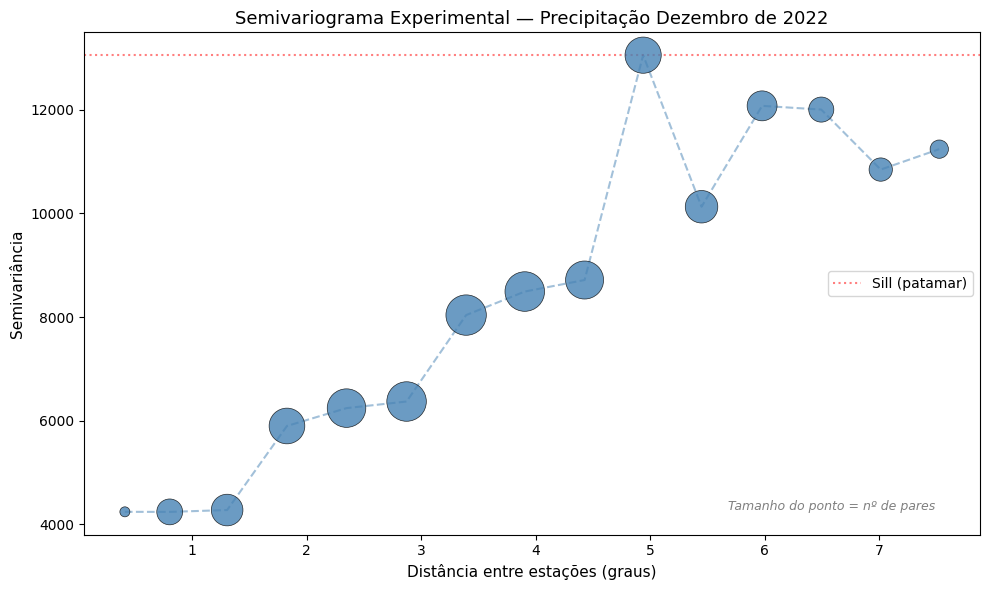

In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o semivariograma experimental
ax.scatter(dist_media, sv_media, s=contagem_bin * 2, c='steelblue',
           edgecolors='black', linewidth=0.5, alpha=0.8, zorder=5)
ax.plot(dist_media, sv_media, '--', color='steelblue', alpha=0.5)

# Identificar visualmente nugget, sill e range
ax.axhline(y=sv_media.max(), color='red', linestyle=':', alpha=0.5, label='Sill (patamar)')

ax.set_xlabel('Distância entre estações (graus)', fontsize=11)
ax.set_ylabel('Semivariância', fontsize=11)
ax.set_title(f'Semivariograma Experimental — Precipitação {DATA_INTERPOLACAO}', fontsize=13)
ax.legend(fontsize=10)

# Nota sobre tamanho dos pontos
ax.text(0.95, 0.05, 'Tamanho do ponto = nº de pares',
        transform=ax.transAxes, ha='right', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

Esse semivariograma, nos mostra que: **a precipitação de dezembro de 2022 não está distribuída de forma aleatória no espaço.**

As estações mais próximas tendem a ter valores mais parecidos entre si, e essa diferença vai aumentando conforme a distância cresce. Isso é exatamente o tipo de comportamento que favorece o uso da **krigagem**.

* **Nas menores distâncias** (algo perto de 0,5 a 1,5 grau), a semivariância já começa em torno de **4.200**.
  Isso sugere um **nugget relativamente alto**. Em termos físicos, quer dizer que já existe uma variação importante mesmo entre estações próximas. Para chuva, isso é bem plausível: precipitação costuma mudar bastante no espaço, ainda mais se houver convecção, relevo ou eventos localizados.

* **Entre cerca de 2 e 4,5 graus**, a semivariância sobe de forma clara, saindo de algo perto de **6.000** para **8.500–8.800**.
  Essa subida mostra que, à medida que a distância aumenta, as estações ficam menos parecidas. Ou seja: **há dependência espacial**.

* **A partir de algo perto de 5 graus**, o gráfico passa a oscilar mais e já não cresce de forma tão organizada.
  Isso indica que você está chegando na faixa em que a correlação espacial enfraquece bastante. Em outras palavras, depois dessa distância, saber o valor em uma estação ajuda bem menos a prever a outra.

Assim, o resultado desse semivariograma é indica que estações próximas tendem a registrar precipitações mais parecidas, enquanto estações distantes tendem a registrar valores mais diferentes. No gráfico, a semivariância cresce com a distância até cerca de 5 graus, indicando dependência espacial. Depois disso, os valores passam a oscilar em torno de um patamar, sugerindo que a influência espacial enfraquece. Esse comportamento é exatamente o que esperamos quando a krigagem faz sentido.

## 3.3 Krigagem Ordinária com pykrige

A biblioteca `pykrige` faz todo o trabalho pesado: ajusta automaticamente um
modelo ao semivariograma e calcula a interpolação com variância.

In [37]:
from pykrige.ok import OrdinaryKriging

# Criar o interpolador Kriging
# O pykrige ajusta automaticamente o modelo do semivariograma
kriging = OrdinaryKriging(
    lon_estacoes,          # Longitude das estações
    lat_estacoes,          # Latitude das estações
    anomalia,
    variogram_model='spherical',  # Modelo do semivariograma
    verbose=False,
    enable_plotting=False,
)

print("Krigagem Ordinária configurada!")
print(f"  Modelo do variograma: spherical")
print(f"  Parâmetros ajustados:")
print(f"    Sill:   {kriging.variogram_model_parameters[0]:.2f}")
print(f"    Range:  {kriging.variogram_model_parameters[1]:.4f}")
print(f"    Nugget: {kriging.variogram_model_parameters[2]:.2f}")

Krigagem Ordinária configurada!
  Modelo do variograma: spherical
  Parâmetros ajustados:
    Sill:   7512.00
    Range:  5.8600
    Nugget: 2533.78


### Executar a interpolação

A Krigagem retorna **dois** resultados: o valor estimado **e** a variância
(incerteza) em cada ponto. Isso é exclusivo da Krigagem!

In [38]:
import numpy as np

# Executar a Krigagem na grade de destino
# Retorna: valores estimados E variância da estimativa
kriging_valores, kriging_variancia = kriging.execute(
    'grid',        # Tipo de saída: grade regular
    grade_lon,     # Vetor de longitudes da grade (1D)
    grade_lat,     # Vetor de latitudes da grade (1D)
)


# A variância pode ser convertida em desvio padrão (mesma unidade da precipitação)
kriging_desvio = np.sqrt(kriging_variancia)

print(f"Krigagem calculada!")
print(f"  Precipitação estimada: {kriging_valores.min():.1f} a {kriging_valores.max():.1f} mm")
print(f"  Desvio padrão (incerteza): {kriging_desvio.min():.1f} a {kriging_desvio.max():.1f} mm")

Krigagem calculada!
  Precipitação estimada: -100.8 a 248.5 mm
  Desvio padrão (incerteza): 57.7 a 105.2 mm


### Mapa da Krigagem: valor estimado + incerteza

A grande vantagem da Krigagem é que ela nos dá **dois mapas**: o de estimativa
e o de incerteza. Regiões longe das estações terão incerteza alta.

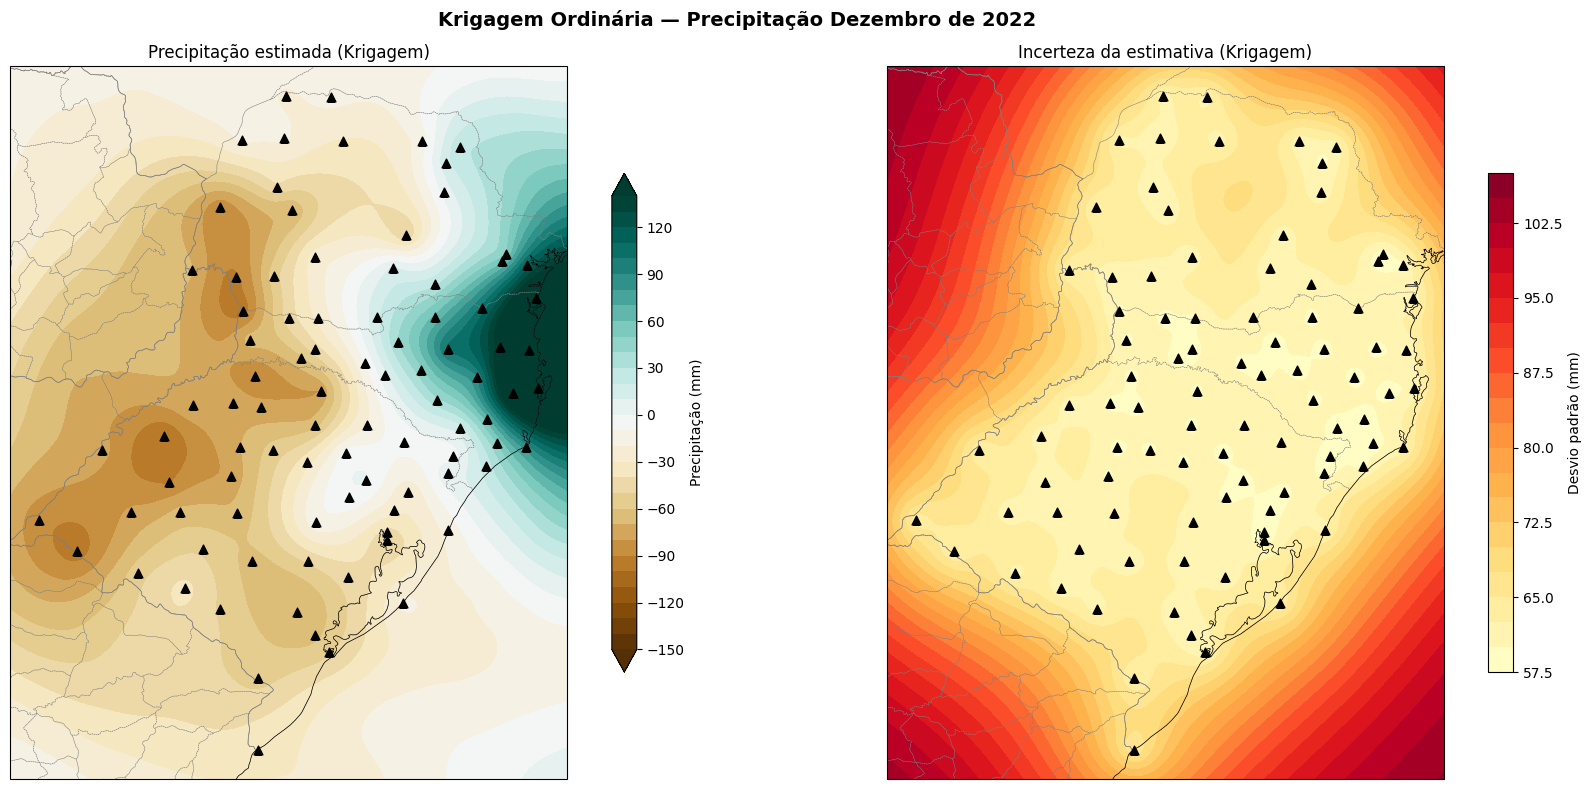

In [39]:
import matplotlib.pyplot as plt
import numpy as np
proj = ccrs.PlateCarree()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': proj})

# --- Mapa 1: Precipitação estimada ---
cf1 = ax1.contourf(grade_lon_2d, grade_lat_2d, kriging_valores, levels=np.arange(-150,150, 10), cmap='BrBG', extend='both', transform=proj)
plt.colorbar(cf1, ax=ax1, shrink=0.7, label='Precipitação (mm)')
ax1.scatter(lon_estacoes, lat_estacoes, c='black', s=40, marker='^', zorder=5, transform=proj)
ax1.set_title('Precipitação estimada (Krigagem)', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax1.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax1.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

# --- Mapa 2: Incerteza (desvio padrão) ---
cf2 = ax2.contourf(grade_lon_2d, grade_lat_2d, kriging_desvio, levels=20, cmap='YlOrRd', transform=proj)
plt.colorbar(cf2, ax=ax2, shrink=0.7, label='Desvio padrão (mm)')
ax2.scatter(lon_estacoes, lat_estacoes, c='black', s=40, marker='^', zorder=5, transform=proj)
ax2.set_title('Incerteza da estimativa (Krigagem)', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax2.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax2.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

fig.suptitle(f'Krigagem Ordinária — Precipitação {DATA_INTERPOLACAO}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Observe os dois mapas:**
>
> No mapa da esquerda (precipitação), a superfície é suave e os valores
> passam (ou se aproximam) dos pontos das estações.
>
> No mapa da direita (incerteza), note como a **incerteza é baixa perto das
> estações** (triângulos pretos) e **alta onde não há estações**. Isso é
> extremamente útil: se uma COP de seca fica em uma região de alta incerteza,
> sabemos que a estimativa de precipitação ali é **menos confiável**.
>
> **Esta é a grande vantagem da Krigagem sobre IDW e Spline:** ela quantifica
> a confiança que podemos ter na estimativa.

---
# Parte 4 — Comparação dos Métodos e Cruzamento com as COPs

## 4.1 Comparação visual: IDW vs Spline vs Krigagem

Vamos colocar os três métodos lado a lado para visualizar as diferenças.

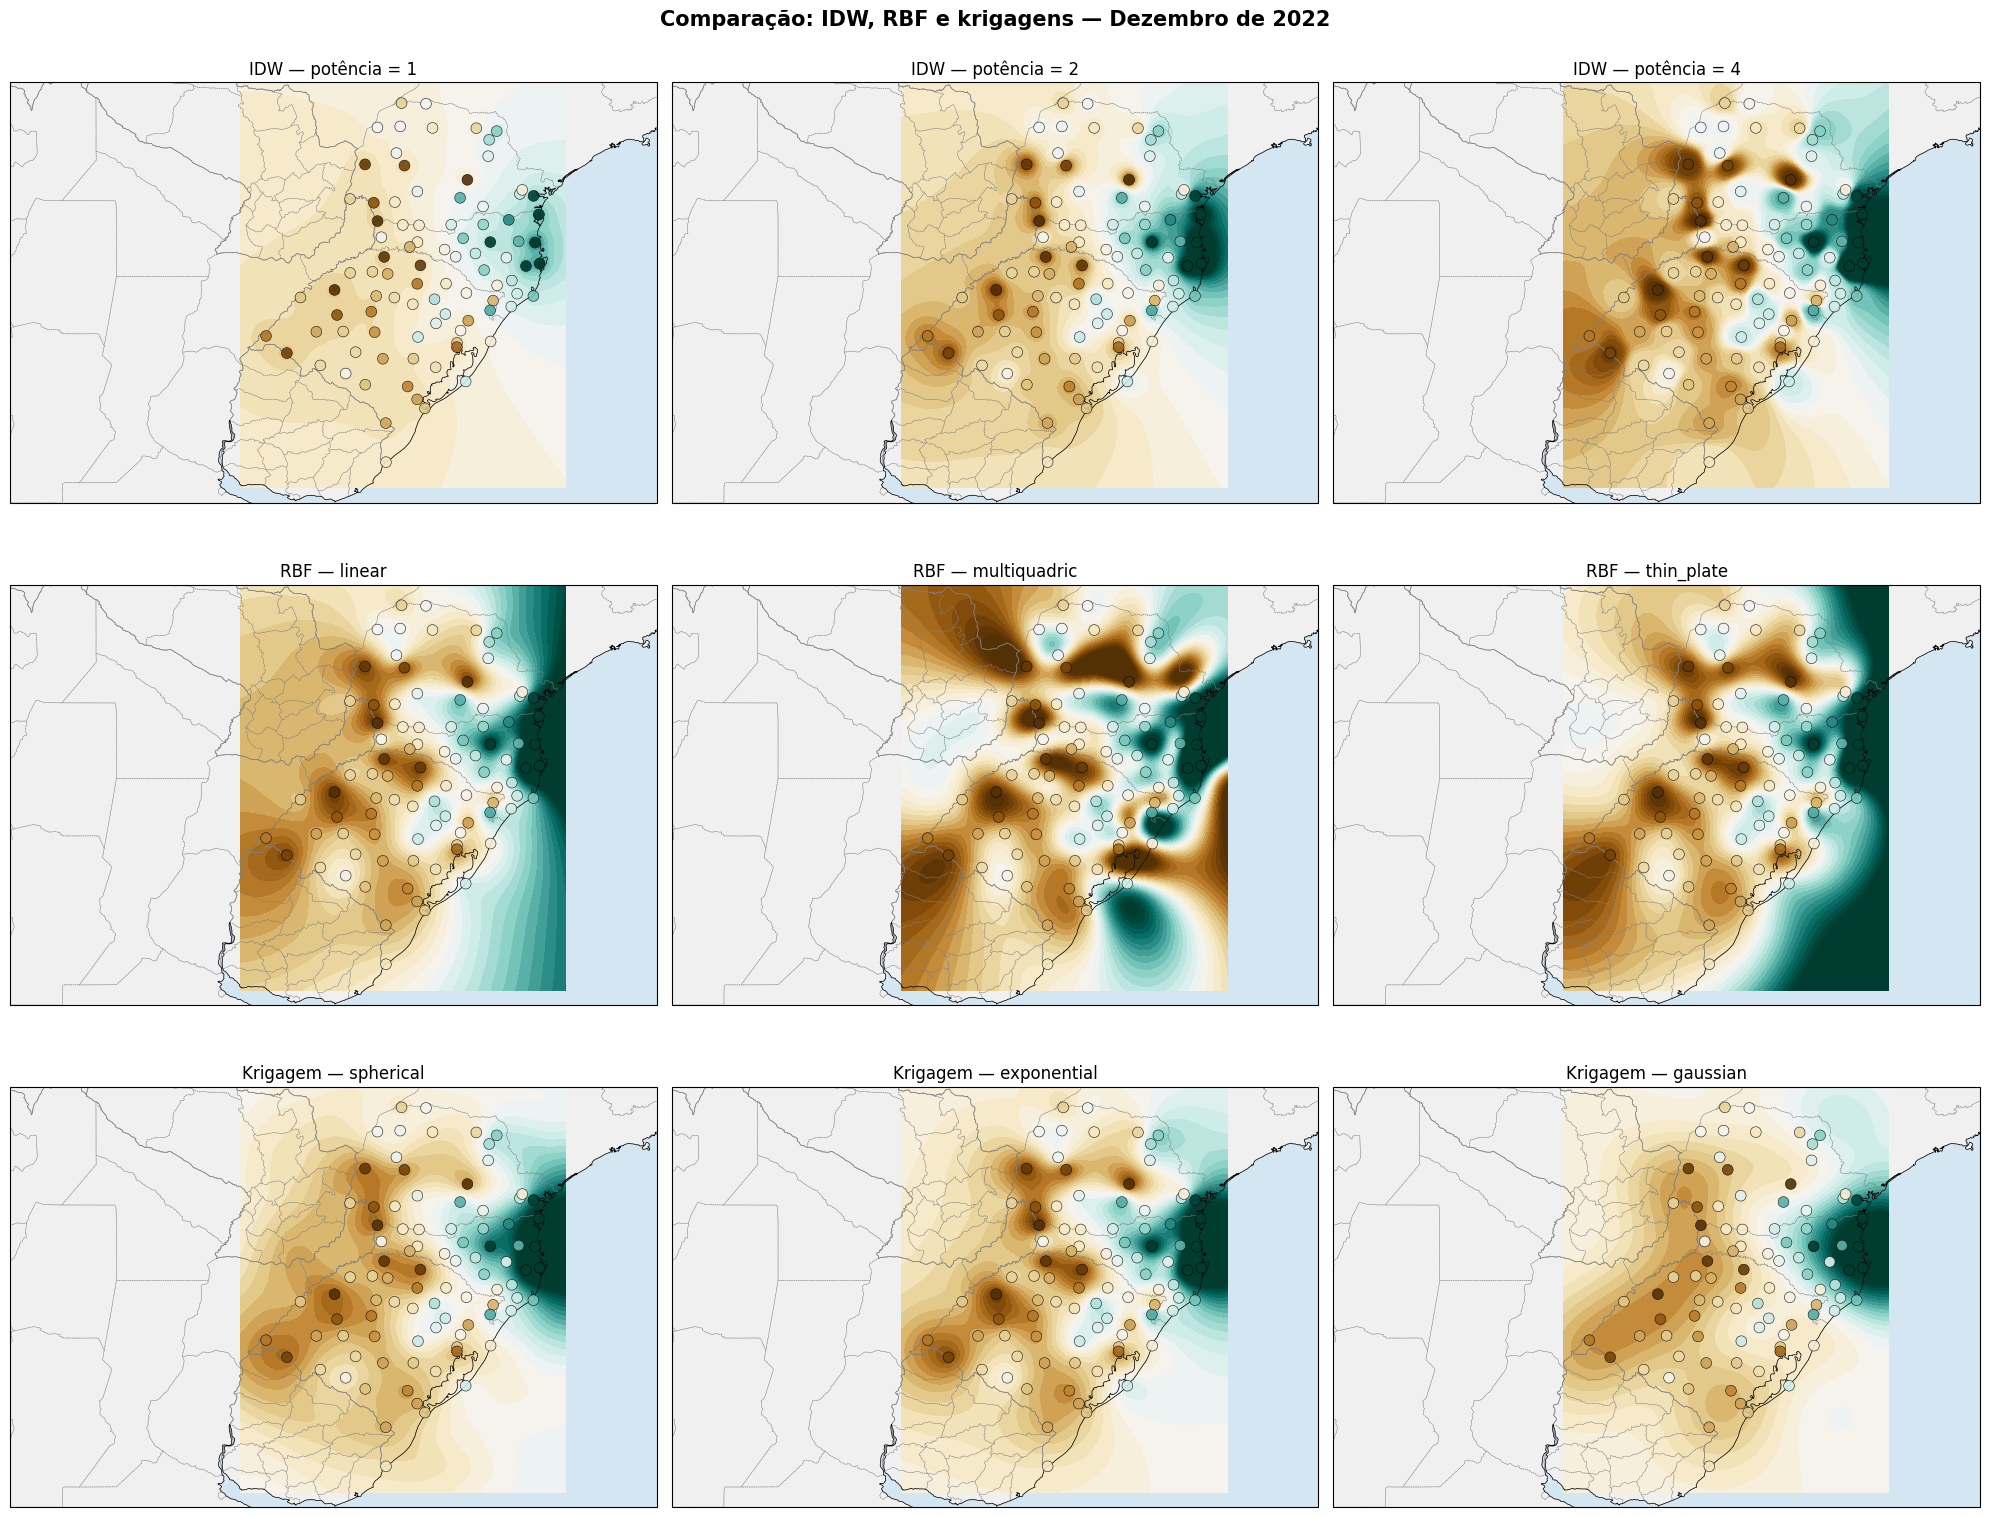

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import Rbf
from pykrige.ok import OrdinaryKriging
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# DADOS DE ENTRADA
DATA_INTERPOLACAO = 'Dezembro de 2022'
proj = ccrs.PlateCarree()

lon_estacoes = anomalia_com_coords['lon_estacao'].values
lat_estacoes = anomalia_com_coords['lat_estacao'].values
anomalia = anomalia_com_coords['anomalia'].values

geometry = [Point(xy) for xy in zip(lon_estacoes, lat_estacoes)]
gdf = gpd.GeoDataFrame(anomalia_com_coords.copy(), geometry=geometry, crs='EPSG:4326')

# GRADE DE INTERPOLAÇÃO
resolucao = 150
xi = np.linspace(lon_estacoes.min() - 0.8, lon_estacoes.max() + 0.8, resolucao)
yi = np.linspace(lat_estacoes.min() - 0.8, lat_estacoes.max() + 0.8, resolucao)
grade_lon_2d, grade_lat_2d = np.meshgrid(xi, yi)
lon_grade_flat = grade_lon_2d.ravel()
lat_grade_flat = grade_lat_2d.ravel()

# CONFIGURAÇÕES DO MAPA
extent = [-65, -45, -35, -22]
levels = np.arange(-150, 151, 10)
cmap = 'BrBG'
vmin, vmax = -150, 150

# IDW
def idw(potencia):
    resultado = np.zeros(len(lon_grade_flat))
    for i in range(len(lon_grade_flat)):
        dist = np.sqrt((lon_estacoes - lon_grade_flat[i])**2 + (lat_estacoes - lat_grade_flat[i])**2)
        dist[dist == 0] = 0.0001
        pesos = 1.0 / (dist ** potencia)
        resultado[i] = np.sum(pesos * anomalia) / np.sum(pesos)
    return resultado.reshape(grade_lon_2d.shape)

# RBF
def rbf(funcao):
    rbf_func = Rbf(lon_estacoes, lat_estacoes, anomalia, function=funcao)
    return rbf_func(grade_lon_2d, grade_lat_2d)

# KRIGAGEM
def krigagem(modelo):
    ok = OrdinaryKriging(lon_estacoes, lat_estacoes, anomalia, variogram_model=modelo, verbose=False, enable_plotting=False, coordinates_type='geographic')
    z, ss = ok.execute('grid', xi, yi)
    return np.asarray(z)

# PLOTAR
def plotar_mapa(ax, superficie, titulo):
    cf = ax.contourf(grade_lon_2d, grade_lat_2d, superficie, levels=levels, cmap=cmap, extend='both', transform=proj)
    ax.scatter(gdf.geometry.x, gdf.geometry.y, c=gdf['anomalia'], cmap=cmap, vmin=vmin, vmax=vmax, s=60, transform=proj, edgecolors='black', linewidth=0.4, alpha=0.9, zorder=5)
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')
    ax.set_title(titulo, fontsize=12)
    return cf

# CALCULAR MÉTODOS
resultados_idw = {'IDW — potência = 1': idw(1), 'IDW — potência = 2': idw(2), 'IDW — potência = 4': idw(4)}
resultados_rbf = {'RBF — linear': rbf('linear'), 'RBF — multiquadric': rbf('multiquadric'), 'RBF — thin_plate': rbf('thin_plate')}
resultados_krig = {'Krigagem — spherical': krigagem('spherical'), 'Krigagem — exponential': krigagem('exponential'), 'Krigagem — gaussian': krigagem('gaussian')}

# PLOTAR 3 PAINÉIS
fig, eixos = plt.subplots(3, 3, figsize=(20, 16), subplot_kw={'projection': proj})
grupos = [resultados_idw, resultados_rbf, resultados_krig]

ultimo_cf = None
for linha in range(3):
    for col in range(3):
        ax = eixos[linha, col]
        nome = list(grupos[linha].keys())[col]
        superficie = grupos[linha][nome]
        ultimo_cf = plotar_mapa(ax, superficie, nome)
        if col == 0:
            ax.set_ylabel('Latitude')

fig.suptitle(f'Comparação: IDW, RBF e krigagens — {DATA_INTERPOLACAO}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

> **O que observar:**
> - O **IDW** tem aspecto mais "angular" com os típicos olhos de boi
> - O **Spline** é mais suave, mas pode gerar valores extremos nas bordas
> - A **Krigagem** é suave E respeita a estrutura dos dados
>
> Na prática, para o contexto do Proagro, a Krigagem é preferível quando
> a incerteza importa (quase sempre). O IDW é uma alternativa rápida quando
> se tem muitas estações e a precisão exata é menos crítica.

## 4.2 Validação cruzada (Leave-One-Out)

Para saber qual método interpola melhor, usamos **validação cruzada**:
1. Remover uma estação dos dados
2. Interpolar o valor naquela posição usando as estações restantes
3. Comparar o valor interpolado com o valor real
4. Repetir para todas as estações

Isso dá uma medida objetiva do erro de cada método.

In [41]:
import numpy as np
from scipy.interpolate import Rbf
from pykrige.ok import OrdinaryKriging

# Listas para guardar os resultados
erros_idw = []
erros_spline = []
erros_kriging = []

n = len(lon_estacoes)

print(f"Validação cruzada Leave-One-Out com {n} estações...")
print()

for i in range(n):
    # Separar: estação i é o "teste", todas as outras são "treino"
    lon_treino = np.delete(lon_estacoes, i)
    lat_treino = np.delete(lat_estacoes, i)
    val_treino = np.delete(anomalia, i)

    lon_teste = lon_estacoes[i]
    lat_teste = lat_estacoes[i]
    val_real  = anomalia[i]

    # --- IDW ---
    dist = np.sqrt((lon_treino - lon_teste)**2 + (lat_treino - lat_teste)**2)
    dist[dist == 0] = 0.0001
    w = 1.0 / (dist ** 2)
    val_idw = np.sum(w * val_treino) / np.sum(w)
    erros_idw.append(val_idw - val_real)

    # --- Spline ---
    rbf_cv = Rbf(lon_treino, lat_treino, val_treino, function='thin_plate')
    val_spline = float(rbf_cv(lon_teste, lat_teste))
    erros_spline.append(val_spline - val_real)

    # --- Krigagem ---
    ok_cv = OrdinaryKriging(
        lon_treino, lat_treino, val_treino,
        variogram_model='spherical', verbose=False, enable_plotting=False
    )
    val_krig, var_krig = ok_cv.execute(
        'points', [lon_teste], [lat_teste]
    )
    erros_kriging.append(float(val_krig) - val_real)

erros_idw = np.array(erros_idw)
erros_spline = np.array(erros_spline)
erros_kriging = np.array(erros_kriging)

print("Validação cruzada concluída!")

Validação cruzada Leave-One-Out com 92 estações...

Validação cruzada concluída!


### Tabela comparativa de métricas de erro

In [42]:
import numpy as np

# Calcular métricas para cada método
def calcular_metricas(erros, nome):
    mae = np.mean(np.abs(erros))       # Erro absoluto médio
    rmse = np.sqrt(np.mean(erros**2))  # Raiz do erro quadrático médio
    vies = np.mean(erros)              # Viés (erro médio)
    return nome, mae, rmse, vies

metricas = [
    calcular_metricas(erros_idw, 'IDW (p=2)'),
    calcular_metricas(erros_spline, 'Spline'),
    calcular_metricas(erros_kriging, 'Krigagem'),
]

print("=" * 60)
print(f"  {'Método':<15} {'MAE (mm)':>10} {'RMSE (mm)':>11} {'Viés (mm)':>11}")
print("=" * 60)
for nome, mae, rmse, vies in metricas:
    print(f"  {nome:<15} {mae:>10.2f} {rmse:>11.2f} {vies:>11.2f}")
print("=" * 60)
print()
print("MAE  = Erro Absoluto Médio (menor é melhor)")
print("RMSE = Raiz do Erro Quadrático Médio (menor é melhor)")
print("Viés = Erro médio (0 = sem viés, + = superestima, - = subestima)")

  Método            MAE (mm)   RMSE (mm)   Viés (mm)
  IDW (p=2)            45.60       65.42       -0.46
  Spline               53.76       72.63       -0.95
  Krigagem             46.41       61.05       -0.45

MAE  = Erro Absoluto Médio (menor é melhor)
RMSE = Raiz do Erro Quadrático Médio (menor é melhor)
Viés = Erro médio (0 = sem viés, + = superestima, - = subestima)


> **Interpretação:**
> - O método com **menor RMSE** é geralmente o mais preciso
> - O **viés** indica se o método tende a superestimar ou subestimar
> - Diferenças pequenas entre métodos são normais — o mais importante é que
>   a Krigagem oferece a **incerteza** como bônus

## 4.3 Cruzamento: precipitação estimada na localização das COPs

Agora vamos fazer algo muito relevante para o Proagro: **estimar a precipitação
no local exato de cada COP**. Isso permite verificar, por exemplo, se uma COP
por Seca ocorreu em um local onde a precipitação realmente foi baixa.

In [43]:
import numpy as np

# Filtrar COPs do período próximo à data de interpolação
data_ref = pd.to_datetime('2022-12')
margem = pd.Timedelta(days=30)

cops_periodo = df_cop[
    (df_cop['nome_evento'] == 'Seca') &
    (df_cop['dt_inicio_evento'] >= data_ref - margem) &
    (df_cop['dt_inicio_evento'] <= data_ref + margem)
].copy()

print(f"COPs de Seca no período: {len(cops_periodo)}")

COPs de Seca no período: 176437


Para cada COP, vamos usar a Krigagem para estimar a precipitação no ponto da gleba
e a incerteza associada.

In [44]:
import numpy as np
from pykrige.ok import OrdinaryKriging

# Coordenadas das COPs
lon_cops = cops_periodo['longitude'].values
lat_cops = cops_periodo['latitude'].values

# Estimar precipitação em cada COP usando a Krigagem
prec_cop_estimada, var_cop_estimada = kriging.execute(
    'points',
    lon_cops,
    lat_cops,
)

# Converter para arrays 1D
prec_cop_estimada = np.array(prec_cop_estimada).ravel()
var_cop_estimada = np.array(var_cop_estimada).ravel()
desvio_cop = np.sqrt(var_cop_estimada)

# Adicionar ao DataFrame
cops_periodo = cops_periodo.copy()
cops_periodo['prec_estimada_mm'] = prec_cop_estimada
cops_periodo['incerteza_mm'] = desvio_cop

print(f"Precipitação estimada nas COPs:")
print(f"  Média:   {prec_cop_estimada.mean():.1f} mm")
print(f"  Mínima:  {prec_cop_estimada.min():.1f} mm")
print(f"  Máxima:  {prec_cop_estimada.max():.1f} mm")
print(f"  Incerteza média: ±{desvio_cop.mean():.1f} mm")

Precipitação estimada nas COPs:
  Média:   -64.0 mm
  Mínima:  -100.6 mm
  Máxima:  185.7 mm
  Incerteza média: ±61.7 mm


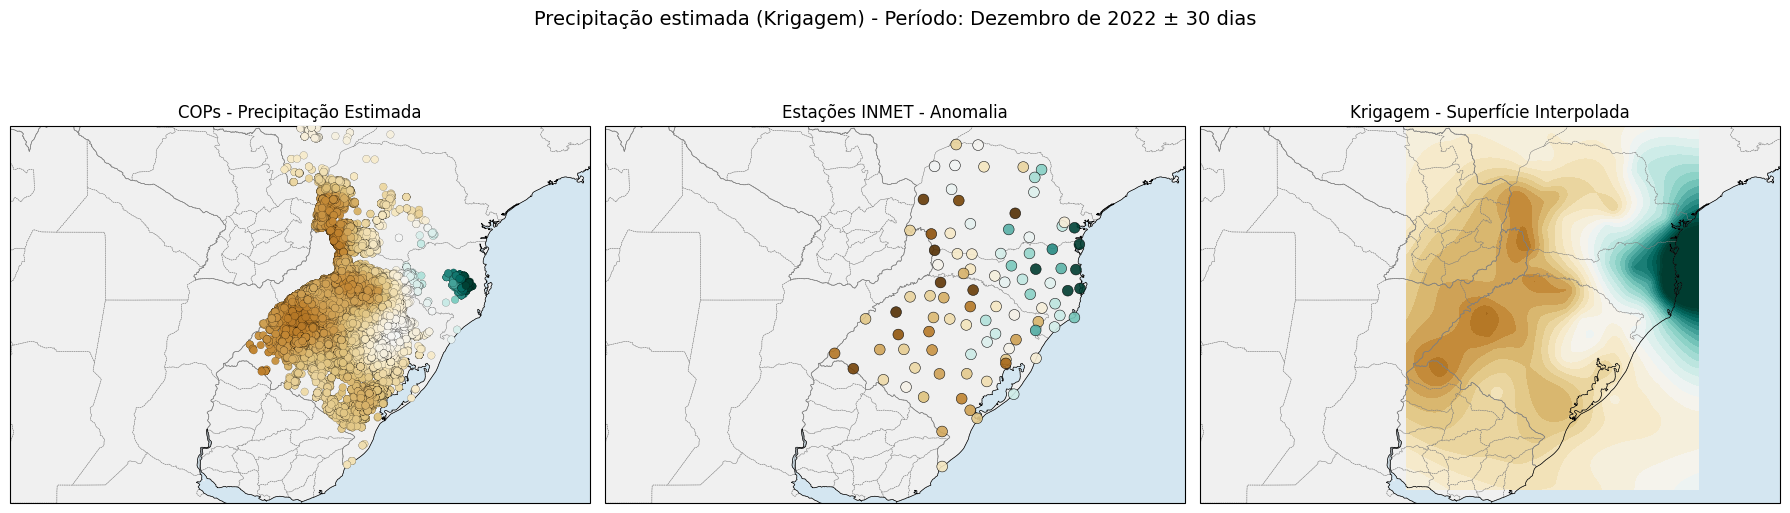

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()
DATA_INTERPOLACAO = 'Dezembro de 2022'

# Criar figura com 3 subplots lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': proj})

# Configurações comuns
levels = np.arange(-150, 151, 10)
cmap = 'BrBG'
vmin, vmax = -150, 150

# ========== AX1: COPs ==========
scatter_cops = ax1.scatter(cops_periodo['longitude'], cops_periodo['latitude'],
                          c=cops_periodo['prec_estimada_mm'],cmap=cmap,
                           vmin=vmin, vmax=vmax, s=30, transform=proj, edgecolors='black',
                           linewidth=0.1, zorder=5)
ax1.set_title('COPs - Precipitação Estimada', fontsize=12)

# ========== AX2: Estações INMET ==========
scatter_inmet = ax2.scatter(gdf.geometry.x, gdf.geometry.y, c=gdf['anomalia'], cmap=cmap,
                           vmin=vmin, vmax=vmax, s=60, transform=proj, edgecolors='black',
                           linewidth=0.4, alpha=0.9, zorder=5)
ax2.set_title('Estações INMET - Anomalia', fontsize=12)

# ========== AX3: Krigagem ==========
ax3.contourf(grade_lon_2d, grade_lat_2d, kriging_valores, levels=levels, cmap=cmap, extend='both', transform=proj)
ax3.set_title('Krigagem - Superfície Interpolada', fontsize=12)

# Adicionar features do mapa em todos os subplots
for ax in [ax1, ax2, ax3]:
    ax.set_extent([-65, -45, -35, -22], crs=proj)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Título geral e colorbar
fig.suptitle(f'Precipitação estimada (Krigagem) - Período: {DATA_INTERPOLACAO} ± 30 dias', fontsize=14)

plt.tight_layout()
plt.show()

> **O que este mapa nos diz:**
>
> Cada ponto colorido é uma COP de Seca. A cor indica a precipitação estimada
> naquele local no dia da interpolação.
>
> - COPs em locais com precipitação **baixa** (cores claras) são **coerentes**
>   com a comunicação de seca — a evidência meteorológica apoia a perda.
> - COPs em locais com precipitação **alta** (cores escuras) podem ser **suspeitas**
>   ou simplesmente indicar que aquele dia específico não era representativo.
>
> ⚠️ **Cuidado:** Um dia de chuva não invalida uma COP de seca. A seca é um
> fenômeno acumulativo — é a falta de chuva ao longo de semanas ou meses.
> Para uma análise real, seria necessário **acumular** a precipitação ao longo
> de todo o período crítico do ciclo fenológico da soja.
>
> **Isso é exatamente o que fazemos no Módulo 3 (Modelagem de Perdas) —
> onde cruzamos séries temporais de precipitação com o calendário de plantio.**

## 4.4 Histograma da incerteza nas COPs

Vamos ver a distribuição da incerteza da Krigagem nas localizações das COPs.
COPs com alta incerteza merecem **cautela adicional** na interpretação.

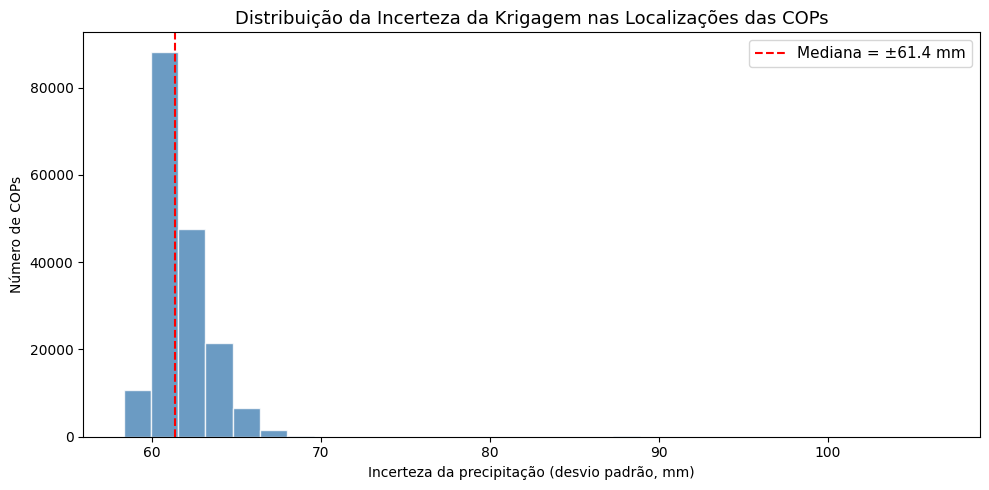

In [46]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(cops_periodo['incerteza_mm'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=cops_periodo['incerteza_mm'].median(), color='red', linestyle='--',
           label=f'Mediana = ±{cops_periodo["incerteza_mm"].median():.1f} mm')

ax.set_xlabel('Incerteza da precipitação (desvio padrão, mm)')
ax.set_ylabel('Número de COPs')
ax.set_title('Distribuição da Incerteza da Krigagem nas Localizações das COPs', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

> **Leitura:** Se muitas COPs caem em locais de alta incerteza (longe das estações),
> isso indica que a rede de monitoramento meteorológico é **insuficiente** para
> aquela região. Nesse caso, fontes complementares como dados em grade
> (MERGE, CHIRPS) são especialmente valiosas.

---
# 📝 Resumo do Bloco 3

| Técnica | Ideia central | Fornece incerteza? | Limitação principal |
|---------|--------------|-------------------|-------------------|
| **IDW** | Mais perto = mais peso | Não | Aspecto "olhos de boi" |
| **Spline** | Superfície suave pelos pontos | Não | Pode gerar valores irreais |
| **Krigagem** | Usa correlação espacial dos dados |  Sim | Mais complexa; requer semivariograma |

### Conceitos-chave deste bloco:

- **Interpolação** estima valores em locais sem medição direta — essencial quando
  a gleba fica longe da estação
- **IDW** é intuitivo (mais perto = mais peso), mas não dá incerteza
- **Spline (RBF)** gera superfícies suaves, mas pode ter overshooting
- **Krigagem** é o padrão-ouro: usa o **semivariograma** para modelar a correlação
  espacial e fornece a **variância da estimativa** (mapa de incerteza)
- A **validação cruzada** (leave-one-out) permite comparar métodos objetivamente
- A **incerteza** é tão importante quanto a estimativa: regiões com alta incerteza
  exigem fontes de dados complementares

### Conexão com os módulos seguintes:

- **Módulo 3 (Modelagem de Perdas):** usa as superfícies interpoladas como insumo
  para verificar coerência entre dados meteorológicos e comunicações de perda
- **Módulo 4 (Aplicações):** cruza interpolação + NDVI + fenologia para construir
  indicadores de plausibilidade
- As técnicas deste bloco se combinam com as do Bloco 1 (KDE) e Bloco 2 (LISA/Gi*)
  em uma abordagem de **convergência de evidências** — nunca decisão baseada em
  um único indicador

---
### Referências Bibliográficas

- **Tobler, W. R.** (1970). A computer movie simulating urban growth in the Detroit region. *Economic Geography*, 46(sup1), 234–240.
- **Krige, D. G.** (1951). A statistical approach to some basic mine valuation problems on the Witwatersrand. *Journal of the Southern African Institute of Mining and Metallurgy*, 52(6), 119–139.
- **Matheron, G.** (1963). Principles of geostatistics. *Economic Geology*, 58(8), 1246–1266.
- **Cressie, N. A. C.** (1993). *Statistics for Spatial Data* (Rev. Ed.). Wiley.
- **Isaaks, E. H. & Srivastava, R. M.** (1989). *An Introduction to Applied Geostatistics.* Oxford University Press.
- **Xavier, A. C. et al.** (2016). Daily gridded meteorological variables in Brazil (1980–2013). *International Journal of Climatology*, 36(6), 2644–2659.
- **Roznik, M. et al.** (2022). How close is close enough? Threshold distances for weather stations to ensure reliable index insurance. *Agricultural Finance Review*, 82(3), 522–541.
- **Acórdão TCU 2493/2024 — Plenário.** Tribunal de Contas da União.